<a href="https://colab.research.google.com/github/Rashed17a/MScFE-610-Financial-Econometrics/blob/main/Project_1/FE_GWP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multicollinearity

### Definition
Multicollinearity is present when two or more independent variables in a regression model are correlated. Multicollinearity can lead to skewed or misleading results.

### Description
In order to filter out multicollinearity, we can use correlation matrix and measure the correlation between the variables.


### Demonstration
Import libraries

In [ ]:
import pandas as pd
import yfinance as yfin
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

from sklearn import preprocessing
from sklearn.decomposition import PCA
plt.rcParams["figure.figsize"] = (12, 9)

In [ ]:
df_data = pd.DataFrame()
tickers = ['NVDA','INTC', 'AAPL', 'AMD', 'SMCI', 'AMZN', 'BTC-USD', 'XOM']

for ticker in tickers:
    df_data[ticker] = yfin.download(ticker, '2014-11-01','2024-11-01')["Close"].pct_change()

df_data.bfill(inplace=True)
corr = df_data.corr()
print(corr)

/tmp/ipykernel_1047/3106325711.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download(ticker, '2014-11-01','2024-11-01')["Close"].pct_change()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1047/3106325711.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download(ticker, '2014-11-01','2024-11-01')["Close"].pct_change()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1047/3106325711.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download(ticker, '2014-11-01','2024-11-01')["Close"].pct_change()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1047/3106325711.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download(ticker, '2014-11-01','2024

             NVDA      INTC      AAPL       AMD      SMCI      AMZN   BTC-USD  \
NVDA     1.000000  0.483603  0.541870  0.579126  0.367510  0.507253  0.189625   
INTC     0.483603  1.000000  0.492404  0.382777  0.294727  0.412298  0.169131   
AAPL     0.541870  0.492404  1.000000  0.419170  0.268159  0.556377  0.172720   
AMD      0.579126  0.382777  0.419170  1.000000  0.285978  0.402451  0.133564   
SMCI     0.367510  0.294727  0.268159  0.285978  1.000000  0.213117  0.084041   
AMZN     0.507253  0.412298  0.556377  0.402451  0.213117  1.000000  0.155601   
BTC-USD  0.189625  0.169131  0.172720  0.133564  0.084041  0.155601  1.000000   
XOM      0.203171  0.317285  0.304125  0.178553  0.203783  0.181164  0.115410   

              XOM  
NVDA     0.203171  
INTC     0.317285  
AAPL     0.304125  
AMD      0.178553  
SMCI     0.203783  
AMZN     0.181164  
BTC-USD  0.115410  
XOM      1.000000  


In [ ]:
pc = df_data[
    [
    'INTC',
    'AAPL',
    'AMD',
    'SMCI',
    'AMZN',
    'BTC-USD',
    'XOM']
]
pca_data = preprocessing.scale(pc)
pca = PCA(n_components=7)
pca.fit(pca_data)
PCA(n_components=7)

pr_var = pca.explained_variance_ratio_
cum_pr = np.cumsum(pca.explained_variance_ratio_)
ind = ["Proportion ofvariance", "Cumulative proportionofvariance"]
cols = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7"]
pd.DataFrame(np.vstack((pr_var, cum_pr)),ind,columns=cols)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Proportion ofvariance,0.394149,0.134284,0.128225,0.116159,0.087323,0.079660,0.060199
Cumulative proportionofvariance,0.394149,0.528433,0.656659,0.772818,0.860141,0.939801,1.000000


In [ ]:
pc_res = pd.DataFrame(pca.components_.T, index=list(pc.columns), columns=cols)
pc_res

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
INTC,0.447072,-0.037874,0.061569,-0.119320,-0.128083,0.857338,-0.170971
AAPL,0.476267,-0.040962,-0.171206,-0.222110,-0.242646,-0.149057,0.782146
AMD,0.405070,-0.141488,-0.266031,0.217915,0.834120,-0.043417,0.000079
SMCI,0.309526,-0.267208,0.382595,0.766718,-0.281151,-0.138912,-0.014690
AMZN,0.433302,-0.042893,-0.423665,-0.179482,-0.326057,-0.387743,-0.584846
BTC-USD,0.193127,0.949790,0.012877,0.244538,0.006275,-0.024364,0.001707
XOM,0.297254,0.039082,0.755042,-0.457246,0.208720,-0.265771,-0.129430


In [ ]:
df_data.rename(columns={'BTC-USD': 'BTC_USD'}, inplace=True)

model_1 = smf.ols(
"NVDA ~INTC+AAPL+AMD+SMCI+AMZN+BTC_USD+XOM",
data=df_data,
).fit()
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   NVDA   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     375.7
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:07:00   Log-Likelihood:                 6110.9
No. Observations:                2516   AIC:                        -1.221e+04
Df Residuals:                    2508   BIC:                        -1.216e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0012      0.000      2.701      0.007       0.000       0.002
INTC           0.2049      0.024      8.676      0.000       0.159       0.251
AAPL           0.3363      0.032     10.674      0.000       0.275       0.398
AMD            0.2716      0.013     20.178      0.000       0.245       0.298
SMCI           0.1108      0.012      9.438      0.000       0.088       0.134
AMZN           0.2533      0.026      9.782      0.000       0.202       0.304
BTC_USD        0.0398      0.011      3.589      0.000       0.018       0.061
XOM           -0.0497      0.026     -1.897      0.058      -0.101       0.002
==============================================================================
Omnibus:                     1172.022   Durbin-Watson:                   2.113
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            49511.899
Skew:                           1.492   Prob(JB):                         0.00
Kurtosis:                      24.526   Cond. No.                         82.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
df_data.rename(columns={'BTC-USD': 'BTC_USD'}, inplace=True)

model_2 = smf.ols(
"NVDA ~INTC+AAPL+AMD+SMCI+BTC_USD+XOM",
data=df_data,
).fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   NVDA   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     407.0
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:07:12   Log-Likelihood:                 6063.8
No. Observations:                2516   AIC:                        -1.211e+04
Df Residuals:                    2509   BIC:                        -1.207e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0013      0.000      2.899      0.004       0.000       0.002
INTC           0.2382      0.024     10.003      0.000       0.191       0.285
AAPL           0.4560      0.030     15.423      0.000       0.398       0.514
AMD            0.2957      0.013     21.939      0.000       0.269       0.322
SMCI           0.1127      0.012      9.423      0.000       0.089       0.136
BTC_USD        0.0450      0.011      3.992      0.000       0.023       0.067
XOM           -0.0578      0.027     -2.166      0.030      -0.110      -0.005
==============================================================================
Omnibus:                     1052.380   Durbin-Watson:                   2.110
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            41297.915
Skew:                           1.280   Prob(JB):                         0.00
Kurtosis:                      22.682   Cond. No.                         73.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
print('VIF_model_1=',round(1/(1-0.493),3))
print('VIF_model_2=',round(1/(1-0.512),3))

VIF_model_1= 1.972
VIF_model_2= 2.049


### Diagram

#### Correlation Matrix

<function matplotlib.pyplot.show(close=None, block=None)>

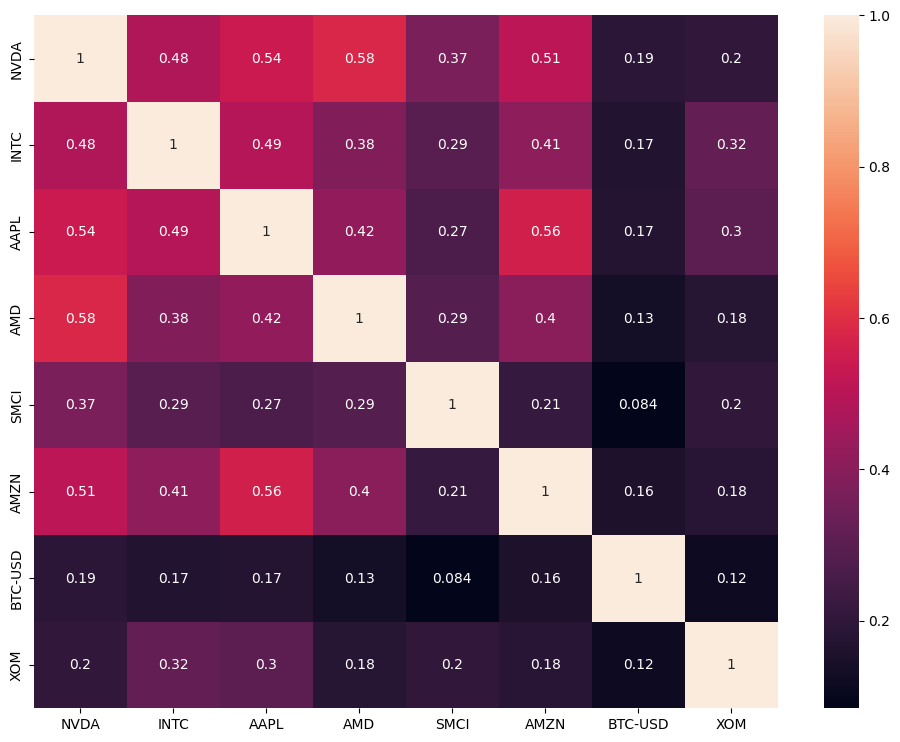

In [ ]:
sns.heatmap(corr, annot=True)
plt.show

### Diagnosis

From the correlation matrix, we can identify the presence of multicollinearity as we have more than 2 daily return pairs \
that are correlated (where |pearson coefficient| > 0.5)

If one seeks indepedent variables for dependant variable NVDA, we can derive the following conclusion:

(1) AAPL, AMZN show a strong positive correlation with NVDA, hence these variables might be a good choice to retain for the regression models

(2) AMZN and AAPL also show a strong positive correlation with each other, this is a potential warning for multicollinearity

(3) The rest of the variables show a moderate/weak correlation with both NVDA and each other, this indicates one should reconsider adding these to the regression models


| Pearson correlation coefficient (r) value | Strength  | Direction |
|--------------------------------------------|-----------|-----------|
| Greater than 0.5                           | Strong    | Positive  |
| Between 0.3 and 0.5                        | Moderate  | Positive  |
| Between 0 and 0.3                          | Weak      | Positive  |
| 0                                          | None      | None      |
| Between 0 and –0.3                         | Weak      | Negative  |
| Between –0.3 and –0.5                      | Moderate  | Negative  |
| Less than –0.5                             | Strong    | Negative  |

https://www.scribbr.com/statistics/pearson-correlation-coefficient/

Based on Principal Component Analysis we can identify 6 variables from the loadings that cover ~94% of the variance:
AAPL, BTC-USD, XOM, SMCI, AMD, INTC
After running the OLS regression models with and without AMZN we can get the conclusion that our model did not improve with removing AMZN based on the adjusted R^2 has decreased. This justifies the results of our correlation test that AMZN can be significant in explaining NVDIA returns. VIF index has increased from 1.972 to 2.049 which means there is more multicollinearity in our model if we exclude AMZN

### Damage

The presence of multicollinearity increases the variances, covariances and standard errors of the coefficients in the regression model which lead to wider confidence intervals and results in less reliable statistical inferences. P-values become less reliable in our analysis and it makes it more complicated to identify each variable’s individual effect. The coefficients become very sensitive to small changes in the model.

### Directions

Drop variables based on |pearson coefficient| > 0.8

Run different regression models and consider choosing variable based on VIF formula

# Skewness

In [ ]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import boxcox, skew
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

/tmp/ipykernel_1047/2789459003.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_nvda = yf.download('NVDA', start='2023-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


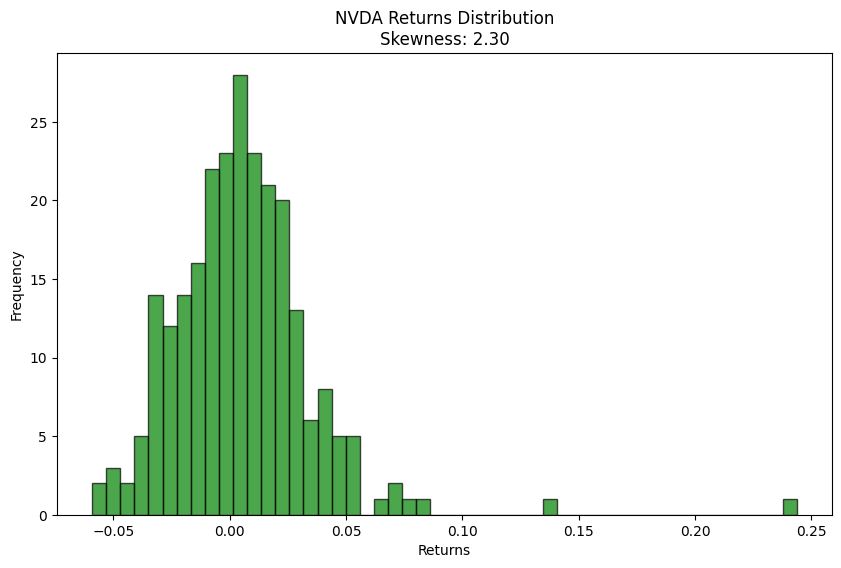

Skewness of NVDA returns: 2.30497


In [ ]:
# Fetch NVIDIA stock data for 2023
data_nvda = yf.download('NVDA', start='2023-01-01', end='2024-01-01')

# Calculate daily returns (percentage change of the adjusted close price)
data_nvda['Returns'] = data_nvda['Close'].pct_change()

# Drop the NaN values from the returns column (first value is NaN)
returns_nvda = data_nvda['Returns'].dropna()

# Calculate skewness of the returns
skewness_nvda = skew(returns_nvda)

# Plot the histogram of the returns
plt.figure(figsize=(10, 6))
plt.hist(returns_nvda, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title(f"NVDA Returns Distribution\nSkewness: {skewness_nvda:.2f}")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()

# Print skewness value
print(f"Skewness of NVDA returns: {skewness_nvda:.5f}")


In [ ]:
from scipy.stats import shapiro, anderson

# Shapiro-Wilk Test
shapiro_stat, shapiro_p_value = shapiro(returns_nvda)
print(f"Shapiro-Wilk Test: Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p_value:.4f}")
if shapiro_p_value < 0.05:
    print("The p-value is less than 0.05. This suggests the data is NOT normally distributed (reject null hypothesis).")
else:
    print("The p-value is greater than 0.05. This suggests the data is normally distributed (fail to reject null hypothesis).")

# Anderson-Darling Test
anderson_result = anderson(returns_nvda)
print(f"Anderson-Darling Test: Statistic = {anderson_result.statistic:.4f}")
for i in range(len(anderson_result.critical_values)):
    significance_level = anderson_result.significance_level[i]
    critical_value = anderson_result.critical_values[i]
    print(f"Critical Value at {significance_level}% significance: {critical_value:.4f}")

if anderson_result.statistic > anderson_result.critical_values[2]:  # 5% significance level
    print("The statistic exceeds the critical value at the 5% level. This suggests the data is NOT normally distributed.")
else:
    print("The statistic does not exceed the critical value at the 5% level. This suggests the data is normally distributed.")

Shapiro-Wilk Test: Statistic = 0.8655, p-value = 0.0000
The p-value is less than 0.05. This suggests the data is NOT normally distributed (reject null hypothesis).
Anderson-Darling Test: Statistic = 2.8799
Critical Value at 15.0% significance: 0.5670
Critical Value at 10.0% significance: 0.6460
Critical Value at 5.0% significance: 0.7750
Critical Value at 2.5% significance: 0.9040
Critical Value at 1.0% significance: 1.0750
The statistic exceeds the critical value at the 5% level. This suggests the data is NOT normally distributed.


Logarithmic Transformation Applied
Skewness after Log Transformation: 2.06439


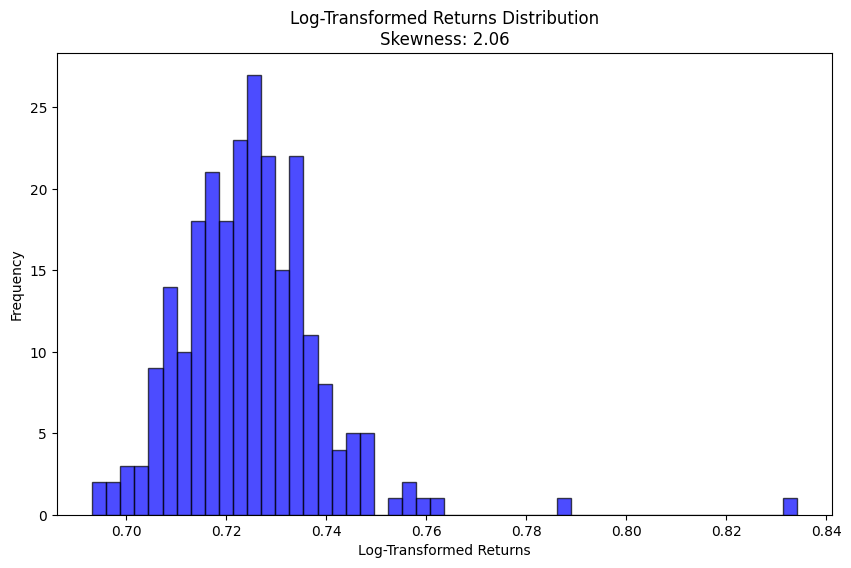

In [ ]:
# Apply logarithmic transformation to reduce skewness
# Ensure all values are positive by adding a constant to the data
log_transformed_returns = np.log1p(returns_nvda - returns_nvda.min() + 1)

# Recalculate skewness after transformation
log_skewness = skew(log_transformed_returns)
print(f"Logarithmic Transformation Applied")
print(f"Skewness after Log Transformation: {log_skewness:.5f}")

# Plot histogram of transformed data
plt.figure(figsize=(10, 6))
plt.hist(log_transformed_returns, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title(f"Log-Transformed Returns Distribution\nSkewness: {log_skewness:.2f}")
plt.xlabel("Log-Transformed Returns")
plt.ylabel("Frequency")
plt.show()

Box-Cox Transformation Applied
Optimal Lambda: -8.61197
Skewness after Box-Cox Transformation: -0.10037


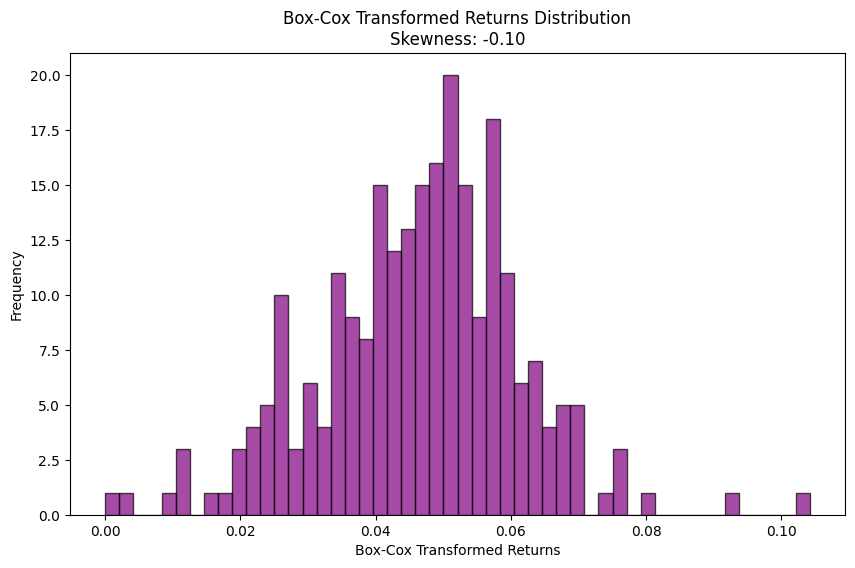

In [ ]:
from scipy.stats import boxcox

# Ensure all values are positive by shifting the data
shifted_returns = returns_nvda - returns_nvda.min() + 1

# Apply Box-Cox transformation
boxcox_transformed_returns, lambda_optimal = boxcox(shifted_returns)

# Recalculate skewness after Box-Cox transformation
boxcox_skewness = skew(boxcox_transformed_returns)
print(f"Box-Cox Transformation Applied")
print(f"Optimal Lambda: {lambda_optimal:.5f}")
print(f"Skewness after Box-Cox Transformation: {boxcox_skewness:.5f}")

# Plot histogram of Box-Cox transformed data
plt.figure(figsize=(10, 6))
plt.hist(boxcox_transformed_returns, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title(f"Box-Cox Transformed Returns Distribution\nSkewness: {boxcox_skewness:.2f}")
plt.xlabel("Box-Cox Transformed Returns")
plt.ylabel("Frequency")
plt.show()


Skewness of Raw Data: 2.30497
Skewness of Log-Transformed Data: 2.06439
Skewness of Box-Cox Transformed Data: -0.10037


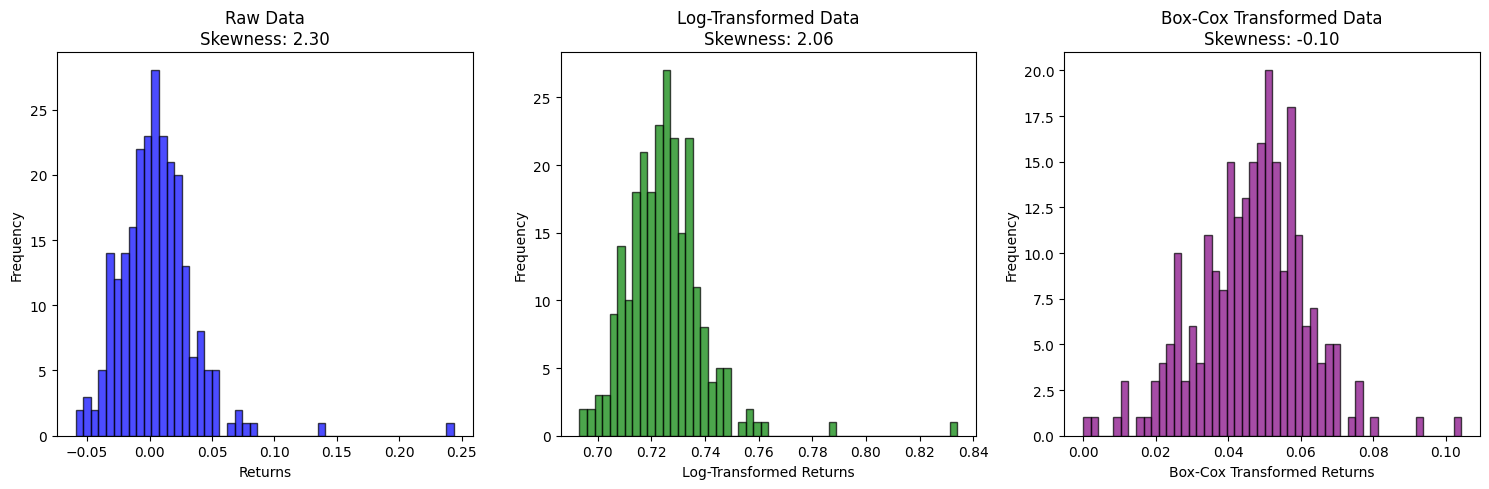

In [ ]:
# Skewness calculations
raw_skewness = skew(returns_nvda)
log_skewness = skew(log_transformed_returns)
boxcox_skewness = skew(boxcox_transformed_returns)

# Print skewness results
print(f"Skewness of Raw Data: {raw_skewness:.5f}")
print(f"Skewness of Log-Transformed Data: {log_skewness:.5f}")
print(f"Skewness of Box-Cox Transformed Data: {boxcox_skewness:.5f}")

# Plot histograms
plt.figure(figsize=(15, 5))

# Raw Data
plt.subplot(1, 3, 1)
plt.hist(returns_nvda, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title(f"Raw Data\nSkewness: {raw_skewness:.2f}")
plt.xlabel("Returns")
plt.ylabel("Frequency")

# Log-Transformed Data
plt.subplot(1, 3, 2)
plt.hist(log_transformed_returns, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title(f"Log-Transformed Data\nSkewness: {log_skewness:.2f}")
plt.xlabel("Log-Transformed Returns")
plt.ylabel("Frequency")

# Box-Cox Transformed Data
plt.subplot(1, 3, 3)
plt.hist(boxcox_transformed_returns, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title(f"Box-Cox Transformed Data\nSkewness: {boxcox_skewness:.2f}")
plt.xlabel("Box-Cox Transformed Returns")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller Test on Box-Cox transformed data
adf_stat, p_value, _, _, critical_values, _ = adfuller(boxcox_transformed_returns)

print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Critical Values:")
for key, value in critical_values.items():
    print(f"  {key}: {value:.4f}")

# Check if data is stationary (p-value < 0.05 means stationary)
if p_value < 0.05:
    print("The data is stationary (reject the null hypothesis).")
else:
    print("The data is not stationary (fail to reject the null hypothesis).")


ADF Statistic: -10.2897
p-value: 0.0000
Critical Values:
  1%: -3.4572
  5%: -2.8734
  10%: -2.5731
The data is stationary (reject the null hypothesis).


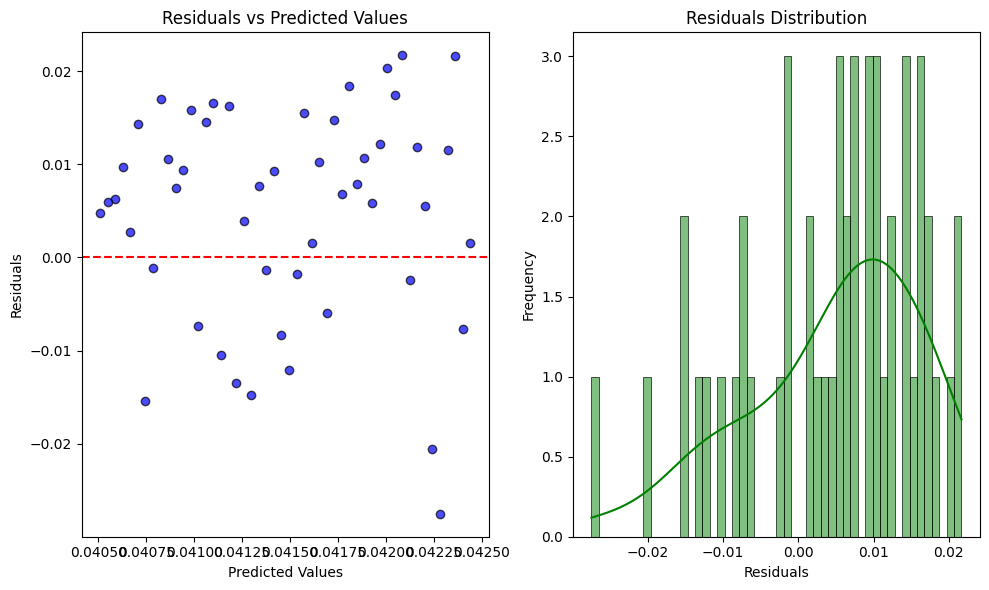

Breusch-Pagan test p-value: 0.0332
The residuals exhibit heteroscedasticity (non-constant variance).


In [ ]:


# Ensure the train-test split and Box-Cox transformed data
# Assuming boxcox_transformed_returns is the transformed data and train/test are split

# Train-test split based on the transformed data
train_size = int(0.8 * len(boxcox_transformed_returns))
train, test = boxcox_transformed_returns[:train_size], boxcox_transformed_returns[train_size:]

# Create features (X) and target (y) for training and testing
X_train = np.arange(len(train)).reshape(-1, 1)  # Use a simple range for X (as we are predicting based on time steps)
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

y_train = train
y_test = test

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))

# Residuals vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, color='blue', edgecolor='black', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# Histogram of residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=50, kde=True, color='green', edgecolor='black')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check for heteroscedasticity using a simple statistical test (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

# Add constant to X_test for the Breusch-Pagan test (regression needs a constant term)
X_test_with_const = add_constant(X_test)

# Performing Breusch-Pagan test for heteroscedasticity
bp_test = het_breuschpagan(residuals, X_test_with_const)
print(f"Breusch-Pagan test p-value: {bp_test[1]:.4f}")

# If the p-value is small (< 0.05), we reject the null hypothesis of homoscedasticity
if bp_test[1] < 0.05:
    print("The residuals exhibit heteroscedasticity (non-constant variance).")
else:
    print("The residuals do not show heteroscedasticity (constant variance).")


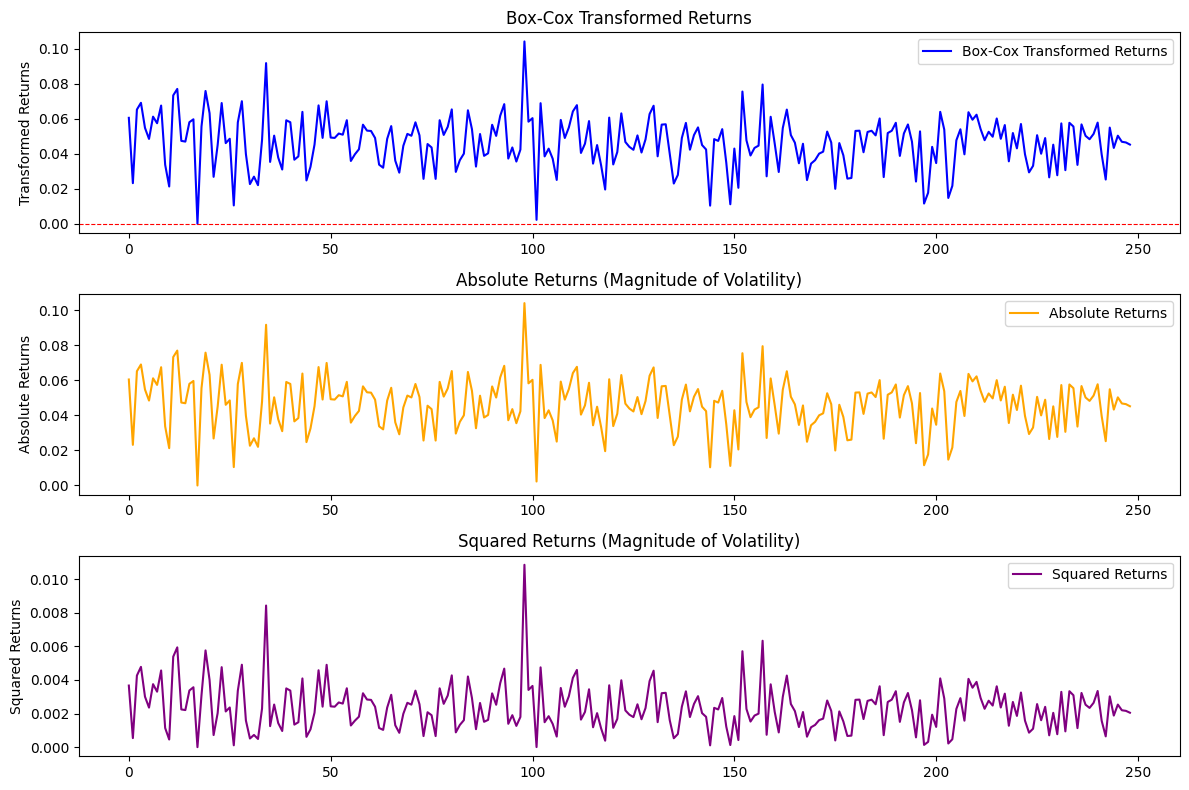

In [ ]:
# Assuming `boxcox_transformed_returns` contains the Box-Cox transformed returns

# Create a DataFrame to hold the transformed returns
volatility_data = pd.DataFrame({
    'Box-Cox Returns': boxcox_transformed_returns
})

# Calculate absolute and squared Box-Cox transformed returns
volatility_data['Absolute Returns'] = np.abs(volatility_data['Box-Cox Returns'])
volatility_data['Squared Returns'] = volatility_data['Box-Cox Returns'] ** 2

# Plot transformed returns and their absolute/squared values
plt.figure(figsize=(12, 8))

# Plot Box-Cox Transformed Returns
plt.subplot(3, 1, 1)
plt.plot(volatility_data.index, volatility_data['Box-Cox Returns'], label="Box-Cox Transformed Returns", color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title("Box-Cox Transformed Returns")
plt.ylabel("Transformed Returns")
plt.legend()

# Plot Absolute Box-Cox Transformed Returns
plt.subplot(3, 1, 2)
plt.plot(volatility_data.index, volatility_data['Absolute Returns'], color='orange', label="Absolute Returns")
plt.title("Absolute Returns (Magnitude of Volatility)")
plt.ylabel("Absolute Returns")
plt.legend()

# Plot Squared Box-Cox Transformed Returns
plt.subplot(3, 1, 3)
plt.plot(volatility_data.index, volatility_data['Squared Returns'], color='purple', label="Squared Returns")
plt.title("Squared Returns (Magnitude of Volatility)")
plt.ylabel("Squared Returns")
plt.legend()

plt.tight_layout()
plt.show()


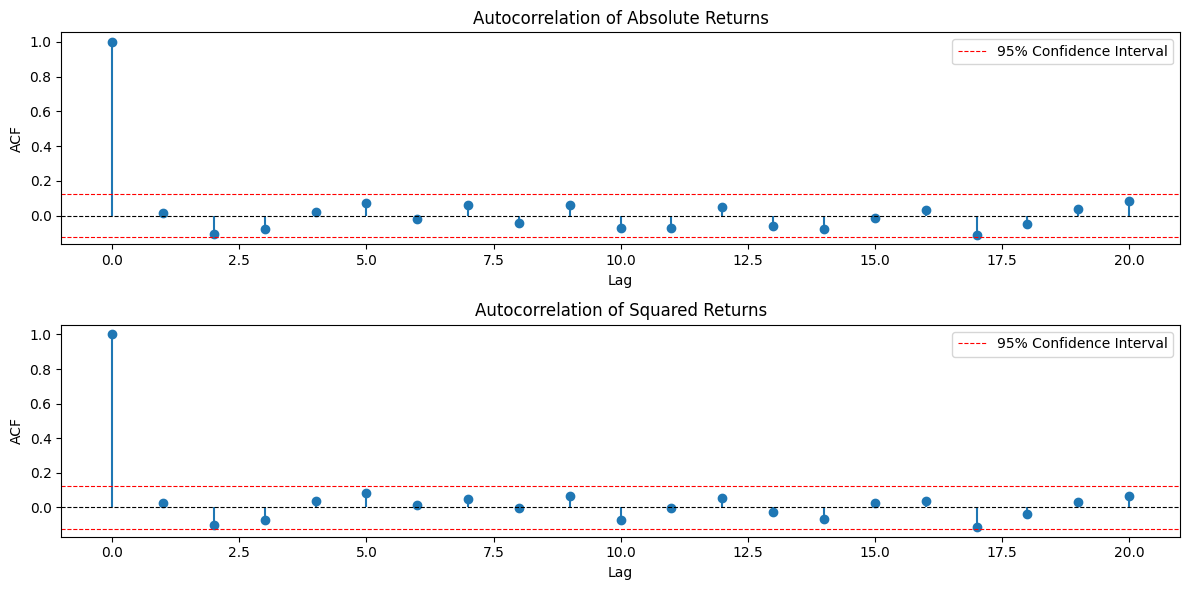

In [ ]:
# Autocorrelation Analysis
abs_acf = sm.tsa.acf(volatility_data['Absolute Returns'], fft=True, nlags=20)
squared_acf = sm.tsa.acf(volatility_data['Squared Returns'], fft=True, nlags=20)

# Plot Autocorrelation for Absolute and Squared Returns
plt.figure(figsize=(12, 6))

# Autocorrelation of Absolute Returns
plt.subplot(2, 1, 1)
plt.stem(range(len(abs_acf)), abs_acf, basefmt=" ")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axhline(1.96 / np.sqrt(len(volatility_data)), color='red', linestyle='--', linewidth=0.8, label='95% Confidence Interval')
plt.axhline(-1.96 / np.sqrt(len(volatility_data)), color='red', linestyle='--', linewidth=0.8)
plt.title("Autocorrelation of Absolute Returns")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.legend()

# Autocorrelation of Squared Returns
plt.subplot(2, 1, 2)
plt.stem(range(len(squared_acf)), squared_acf, basefmt=" ")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axhline(1.96 / np.sqrt(len(volatility_data)), color='red', linestyle='--', linewidth=0.8, label='95% Confidence Interval')
plt.axhline(-1.96 / np.sqrt(len(volatility_data)), color='red', linestyle='--', linewidth=0.8)
plt.title("Autocorrelation of Squared Returns")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

# Calculate autocorrelation of absolute and squared returns
abs_acf = acf(volatility_data['Absolute Returns'], fft=True, nlags=20)
squared_acf = acf(volatility_data['Squared Returns'], fft=True, nlags=20)

# Durbin-Watson Test
dw_abs = durbin_watson(volatility_data['Absolute Returns'])
dw_squared = durbin_watson(volatility_data['Squared Returns'])
print(f"Durbin-Watson Test:")
print(f"  Absolute Returns: {dw_abs:.4f}")
print(f"  Squared Returns: {dw_squared:.4f}")

# Ljung-Box Test
ljung_box_abs = acorr_ljungbox(volatility_data['Absolute Returns'], lags=20, return_df=True)
ljung_box_squared = acorr_ljungbox(volatility_data['Squared Returns'], lags=20, return_df=True)

# Print Ljung-Box Test Results
print("\nLjung-Box Test Results for Absolute Returns:")
print(ljung_box_abs)

print("\nLjung-Box Test Results for Squared Returns:")
print(ljung_box_squared)

# Conclusion for the last lag (lag 20)
if ljung_box_abs['lb_pvalue'].iloc[-1] < 0.05:
    print("\nSignificant autocorrelation in Absolute Returns (reject null hypothesis).")
else:
    print("\nNo significant autocorrelation in Absolute Returns (fail to reject null hypothesis).")

if ljung_box_squared['lb_pvalue'].iloc[-1] < 0.05:
    print("Significant autocorrelation in Squared Returns (reject null hypothesis).")
else:
    print("No significant autocorrelation in Squared Returns (fail to reject null hypothesis).")


Durbin-Watson Test:
  Absolute Returns: 0.1825
  Squared Returns: 0.5060

Ljung-Box Test Results for Absolute Returns:
      lb_stat  lb_pvalue
1    0.083274   0.772908
2    2.950301   0.228744
3    4.401049   0.221288
4    4.514599   0.340820
5    5.983558   0.307822
6    6.096353   0.412484
7    7.115715   0.416932
8    7.601798   0.473301
9    8.625701   0.472517
10   9.911692   0.448275
11  11.202139   0.426487
12  11.905651   0.453286
13  12.828760   0.461124
14  14.344643   0.424363
15  14.393187   0.495942
16  14.632594   0.551694
17  17.831861   0.399522
18  18.440345   0.427018
19  18.805139   0.469399
20  20.621586   0.419699

Ljung-Box Test Results for Squared Returns:
      lb_stat  lb_pvalue
1    0.187074   0.665363
2    2.695616   0.259809
3    3.922951   0.269905
4    4.246550   0.373666
5    6.064078   0.300034
6    6.130954   0.408682
7    6.684322   0.462471
8    6.688994   0.570529
9    7.932503   0.540962
10   9.301075   0.503789
11   9.306638   0.593611
12  10.1511

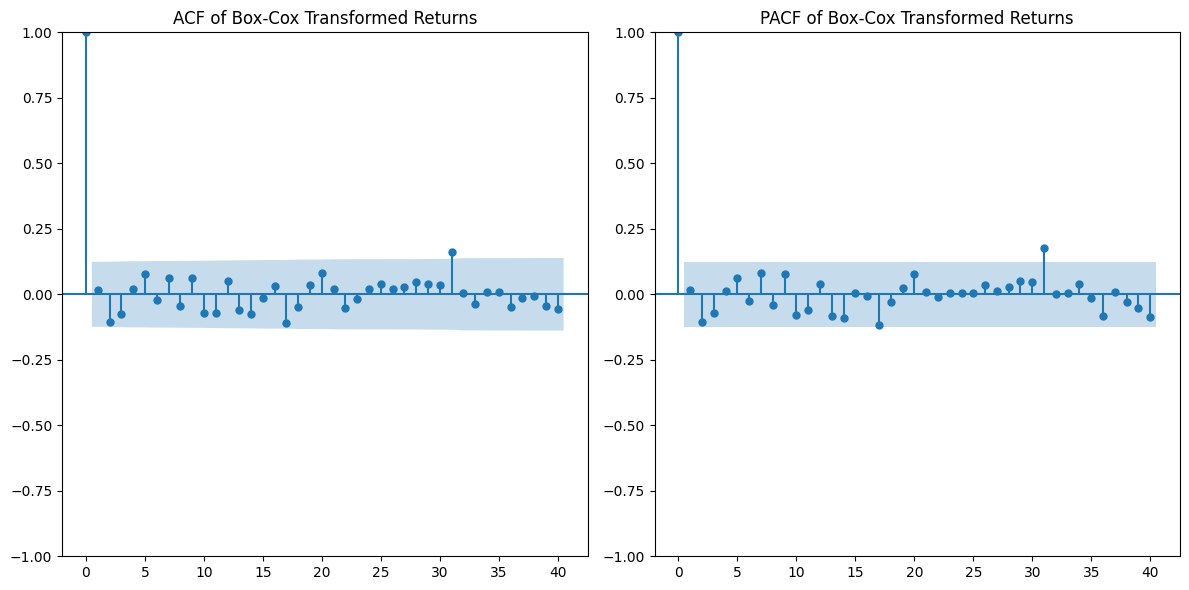

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for Box-Cox transformed returns
plt.figure(figsize=(12, 6))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(boxcox_transformed_returns, lags=40, ax=plt.gca(), title="ACF of Box-Cox Transformed Returns")

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(boxcox_transformed_returns, lags=40, ax=plt.gca(), title="PACF of Box-Cox Transformed Returns")

plt.tight_layout()
plt.show()


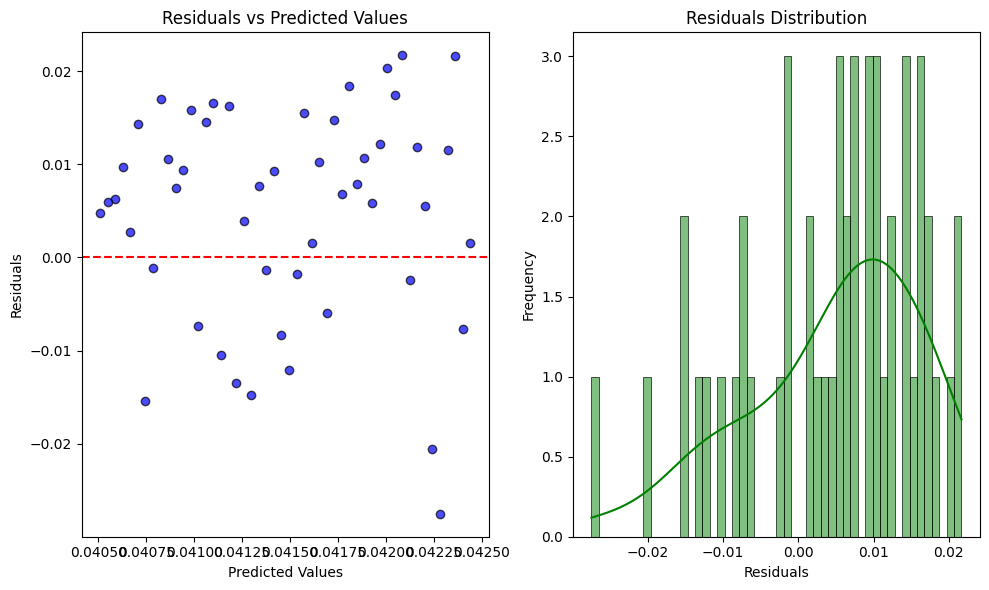

Breusch-Pagan test p-value: 0.0332
The residuals exhibit heteroscedasticity (non-constant variance).


In [ ]:
# Ensure the train-test split and Box-Cox transformed data
# Assuming boxcox_transformed_returns is the transformed data and train/test are split

# Train-test split based on the transformed data
train_size = int(0.8 * len(boxcox_transformed_returns))
train, test = boxcox_transformed_returns[:train_size], boxcox_transformed_returns[train_size:]

# Create features (X) and target (y) for training and testing
X_train = np.arange(len(train)).reshape(-1, 1)  # Use a simple range for X (as we are predicting based on time steps)
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

y_train = train
y_test = test

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))

# Residuals vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, color='blue', edgecolor='black', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

# Histogram of residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=50, kde=True, color='green', edgecolor='black')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check for heteroscedasticity using a simple statistical test (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

# Add constant to X_test for the Breusch-Pagan test (regression needs a constant term)
X_test_with_const = add_constant(X_test)

# Performing Breusch-Pagan test for heteroscedasticity
bp_test = het_breuschpagan(residuals, X_test_with_const)
print(f"Breusch-Pagan test p-value: {bp_test[1]:.4f}")

# If the p-value is small (< 0.05), we reject the null hypothesis of homoscedasticity
if bp_test[1] < 0.05:
    print("The residuals exhibit heteroscedasticity (non-constant variance).")
else:
    print("The residuals do not show heteroscedasticity (constant variance).")





                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.404
Model:                            WLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     133.3
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           6.86e-24
Time:                        20:08:22   Log-Likelihood:                 682.13
No. Observations:                 199   AIC:                            -1360.
Df Residuals:                     197   BIC:                            -1354.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0502      0.000    132.169      0.0

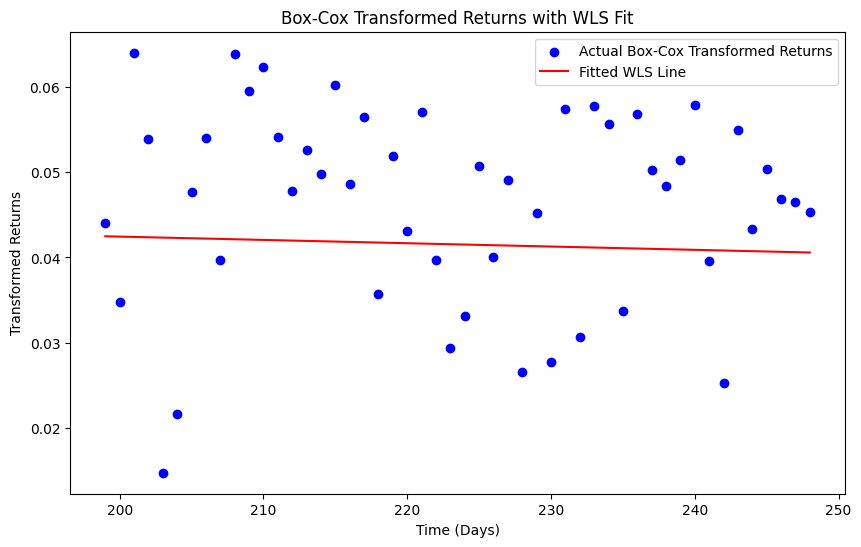

In [ ]:
# Predict on the training set
y_pred_train = model.predict(X_train)

# Calculate residuals for training data
residuals_train = y_train - y_pred_train

# Add constant to X_train for WLS (intercept term)
X_train_with_const = add_constant(X_train)

# Calculate the weights for WLS (inverse of squared residuals from training data)
weights = 1 / (residuals_train ** 2)

# Fit the WLS model using the computed weights
wls_model = sm.WLS(y_train, X_train_with_const, weights=weights).fit()

# Print the summary of the WLS model
print(wls_model.summary())

# Predict on the test set using WLS
X_test_with_const = add_constant(X_test)
y_pred_wls = wls_model.predict(X_test_with_const)

# Calculate model performance metrics for WLS
mse_wls = mean_squared_error(y_test, y_pred_wls)
rmse_wls = np.sqrt(mse_wls)
r2_wls = r2_score(y_test, y_pred_wls)

# Print the performance metrics for WLS
print(f"Mean Squared Error (WLS): {mse_wls:.5f}")
print(f"Root Mean Squared Error (WLS): {rmse_wls:.5f}")
print(f"R-squared (WLS): {r2_wls:.5f}")

# Plot the actual returns vs predicted WLS values
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Box-Cox Transformed Returns')
plt.plot(X_test, y_pred_wls, color='red', label='Fitted WLS Line')
plt.title("Box-Cox Transformed Returns with WLS Fit")
plt.xlabel("Time (Days)")
plt.ylabel("Transformed Returns")
plt.legend()
plt.show()


# Sensitivity to outliers

## Section 1
It involves fetching Nvidia stock data using the `yfinance` library, calculating daily returns, and preparing the data for analysis. The dataset spans from January 1, 2023, to January 1, 2024.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Fetch Nvidia stock data
nvidia = yf.download('NVDA', start='2023-01-01', end='2024-01-01')
# Calculate daily returns
nvidia['Daily Returns'] = nvidia['Close'].pct_change()
# Drop NaN values
nvidia.dropna(inplace=True)
# Display the first few rows
nvidia.head()

/tmp/ipykernel_1047/1438741879.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvidia = yf.download('NVDA', start='2023-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Daily Returns
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,
Date,,,,,,
2023-01-04,14.734251,14.838147,14.226760,14.552434,431324000,0.030318
2023-01-05,14.250734,14.549435,14.133851,14.476508,389168000,-0.032816
2023-01-06,14.844142,14.994991,14.019967,14.459527,405044000,0.041640
2023-01-09,15.612370,16.039942,15.125857,15.268715,504231000,0.051753
2023-01-10,15.893088,15.946035,15.456525,15.491490,384101000,0.017980


## Section 2
This analysis identifies outliers in Nvidia's daily returns using two statistical methods: **Z-Scores** and the **Interquartile Range (IQR)**. It includes:
- A comparison of outliers detected by both methods.
- Visualizations to highlight the impact of outliers on data distribution and time-series trends.

**Methods**
1. **Z-Scores**:
   - Calculates the standardized score for each data point.
   - Flags values as outliers if their absolute Z-Score exceeds 3.

2. **Interquartile Range (IQR)**:
   - Computes the IQR as the difference between the 75th and 25th percentiles.
   - Identifies outliers as values lying 1.5 times below the 25th percentile or above the 75th percentile.

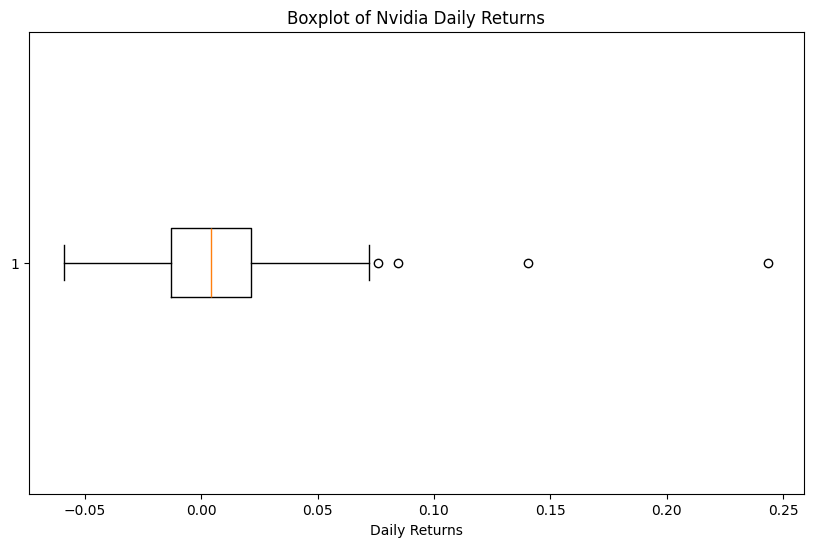

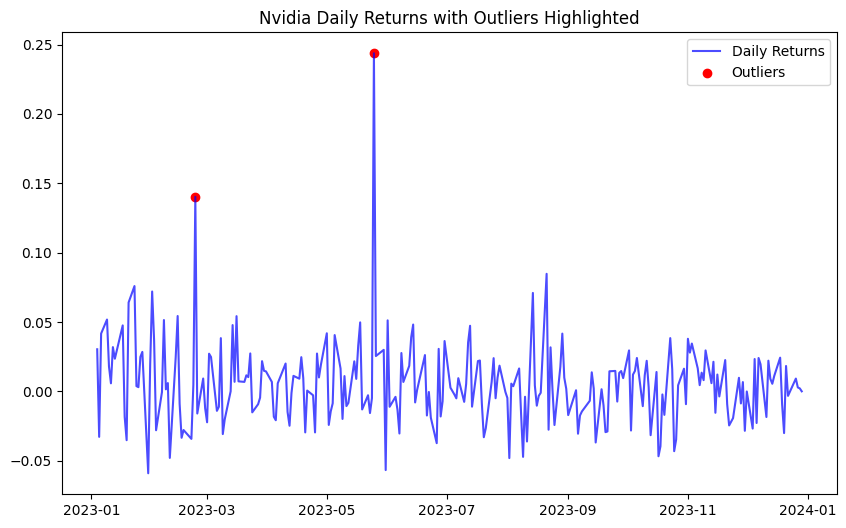

In [ ]:
# Detect outliers using z-scores
nvidia['Z-Score'] = (nvidia['Daily Returns'] - nvidia['Daily Returns'].mean()) / nvidia['Daily Returns'].std()
nvidia['Outlier (Z-Score)'] = np.abs(nvidia['Z-Score']) > 3

# IQR method
Q1 = nvidia['Daily Returns'].quantile(0.25)
Q3 = nvidia['Daily Returns'].quantile(0.75)
IQR = Q3 - Q1
nvidia['Outlier (IQR)'] = (nvidia['Daily Returns'] < Q1 - 1.5 * IQR) | (nvidia['Daily Returns'] > Q3 + 1.5 * IQR)

# Count outliers
z_outliers = nvidia['Outlier (Z-Score)'].sum()
iqr_outliers = nvidia['Outlier (IQR)'].sum()

# Boxplot of daily returns
plt.figure(figsize=(10, 6))
plt.boxplot(nvidia['Daily Returns'], vert=False)
plt.title("Boxplot of Nvidia Daily Returns")
plt.xlabel("Daily Returns")
plt.show()

# Time-series plot with outliers highlighted
plt.figure(figsize=(10, 6))
plt.plot(nvidia.index, nvidia['Daily Returns'], label='Daily Returns', color='blue', alpha=0.7)
plt.scatter(nvidia.index[nvidia['Outlier (Z-Score)']],
            nvidia['Daily Returns'][nvidia['Outlier (Z-Score)']],
            color='red', label='Outliers', marker='o')
plt.title("Nvidia Daily Returns with Outliers Highlighted")
plt.legend()
plt.show()

## Section 3
This section applies linear regression models to both the original and winsorized Nvidia daily returns data. The goal is to evaluate the impact of outlier mitigation on model performance using metrics such as **R-squared** and **Root Mean Squared Error (RMSE)**.

**Steps:**
1. **Winsorization**: Mitigate outliers in the daily returns data by capping extreme values (5% in each tail).
2. **Data Preparation**: Add a time-based predictor column (`Day`) for the regression model.
3. **Model Fitting**: Fit separate linear regression models for:
   - Original daily returns
   - Winsorized daily returns
4. **Model Evaluation**: Compare the models using R-squared and RMSE.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from scipy.stats.mstats import winsorize

# Suppress future warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Linear regression on original and winsorized data
# Winsorize daily returns (capping at 5% both tails)
nvidia['Winsorized Returns'] = winsorize(nvidia['Daily Returns'], limits=[0.05, 0.05])

# Prepare data
nvidia['Day'] = np.arange(len(nvidia))  # Add a 'Day' column to use as a predictor
X_original = nvidia[['Day']]
y_original = nvidia['Daily Returns']
y_winsorized = nvidia['Winsorized Returns']

# Fit linear regression models
model_original = LinearRegression().fit(X_original, y_original)
model_winsorized = LinearRegression().fit(X_original, y_winsorized)

# Predict and evaluate models
y_pred_original = model_original.predict(X_original)
y_pred_winsorized = model_winsorized.predict(X_original)

# Calculate R-squared and RMSE
r2_original = r2_score(y_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_original, y_pred_original))

r2_winsorized = r2_score(y_winsorized, y_pred_winsorized)
rmse_winsorized = np.sqrt(mean_squared_error(y_winsorized, y_pred_winsorized))

# Print metrics
print("Original Data Metrics:")
print(f"R-squared: {r2_original:.4f}, RMSE: {rmse_original:.4f}")
print("\nWinsorized Data Metrics:")
print(f"R-squared: {r2_winsorized:.4f}, RMSE: {rmse_winsorized:.4f}")

Original Data Metrics:
R-squared: 0.0163, RMSE: 0.0302

Winsorized Data Metrics:
R-squared: 0.0156, RMSE: 0.0230


## Section 4
This visualization compares the distributions of original and winsorized daily returns. Winsorization reduces the impact of extreme outliers by capping values at the tails of the distribution.

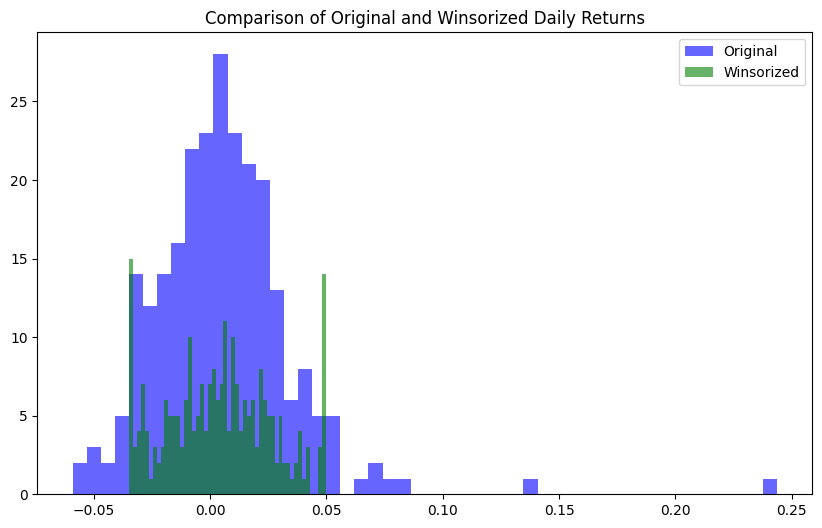

In [ ]:
# Compare original and winsorized distributions
plt.figure(figsize=(10, 6))
plt.hist(nvidia['Daily Returns'], bins=50, alpha=0.6, label='Original', color='blue')
plt.hist(nvidia['Winsorized Returns'], bins=50, alpha=0.6, label='Winsorized', color='green')
plt.title("Comparison of Original and Winsorized Daily Returns")
plt.legend()
plt.show()

## Section 5
This section compares the summary statistics and volatility (standard deviation) of the original and winsorized daily returns. Winsorization typically reduces extreme variability, reflected in lower volatility values.

In [ ]:
# Summary statistics before and after winsorization
print("Original Data Statistics:")
print(nvidia['Daily Returns'].describe())
print("\nWinsorized Data Statistics:")
print(nvidia['Winsorized Returns'].describe())

# Check the reduction in volatility (standard deviation)
original_volatility = nvidia['Daily Returns'].std()
winsorized_volatility = nvidia['Winsorized Returns'].std()

print(f"\nVolatility Reduction:\nOriginal: {original_volatility:.4f}, Winsorized: {winsorized_volatility:.4f}")

Original Data Statistics:
count    249.000000
mean       0.005442
std        0.030525
min       -0.059072
25%       -0.013069
50%        0.004315
75%        0.021308
max        0.243696
Name: Daily Returns, dtype: float64

Winsorized Data Statistics:
count    249.000000
mean       0.004234
std        0.023204
min       -0.034778
25%       -0.013069
50%        0.004315
75%        0.021308
max        0.049705
Name: Winsorized Returns, dtype: float64

Volatility Reduction:
Original: 0.0305, Winsorized: 0.0232


# GARCH Volatility

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001657. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Shape of forecast.variance.values: (1, 30)
Forecast.variance.values: [[ 862.82273319  879.78941864  895.93059515  911.28642762  925.89512673
   939.79304401  953.01476234  965.59318198  977.55960242  988.94380032
   999.77410352 1010.0774616  1019.87951292 1029.20464841 1038.07607226
  1046.51585967 1054.54501179 1062.18350795 1069.4503554  1076.36363659
  1082.94055418 1089.19747384 1095.14996498 1100.81283946 1106.20018851
  1111.32541772 1116.20128046 1120.83990958 1125.2528476  1129.45107547]]
NVDA Volatility Metrics:
mean_squared_error: 1061581.1030948146
mean_absolute_error: 1026.8568583035913
mean_absolute_percentage_error: 176.88933837923233
forecast_volatility: 1026.1356804766494
actual_volatility: 25.031525059121474
volatility_difference: 1001.104155417528
volatility_ratio: 40.99373402351792
explained_variance: -22.760118283329533
Iteration:      1,   Func. Count:      6,   Neg. LLF: 16862.32432521589
Iteration:      2,   Func. Count:     16,   Neg. LLF: 239.90925613639308
It

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001574. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00124. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:6

Iteration:      7,   Func. Count:     53,   Neg. LLF: -1679.1183208416903
Iteration:      8,   Func. Count:     58,   Neg. LLF: -1679.118333102428
Iteration:      9,   Func. Count:     62,   Neg. LLF: -1679.1183331023956
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1679.118333102428
            Iterations: 9
            Function evaluations: 62
            Gradient evaluations: 9

Cross-Validation Volatility Metrics:
Fold 1 Volatility Ratio: 0.045097920756225006
Fold 2 Volatility Ratio: 0.06620796451436471
Fold 3 Volatility Ratio: 0.032245915267497344
Fold 4 Volatility Ratio: 0.035313678342265814
Fold 5 Volatility Ratio: 0.06047683544433411


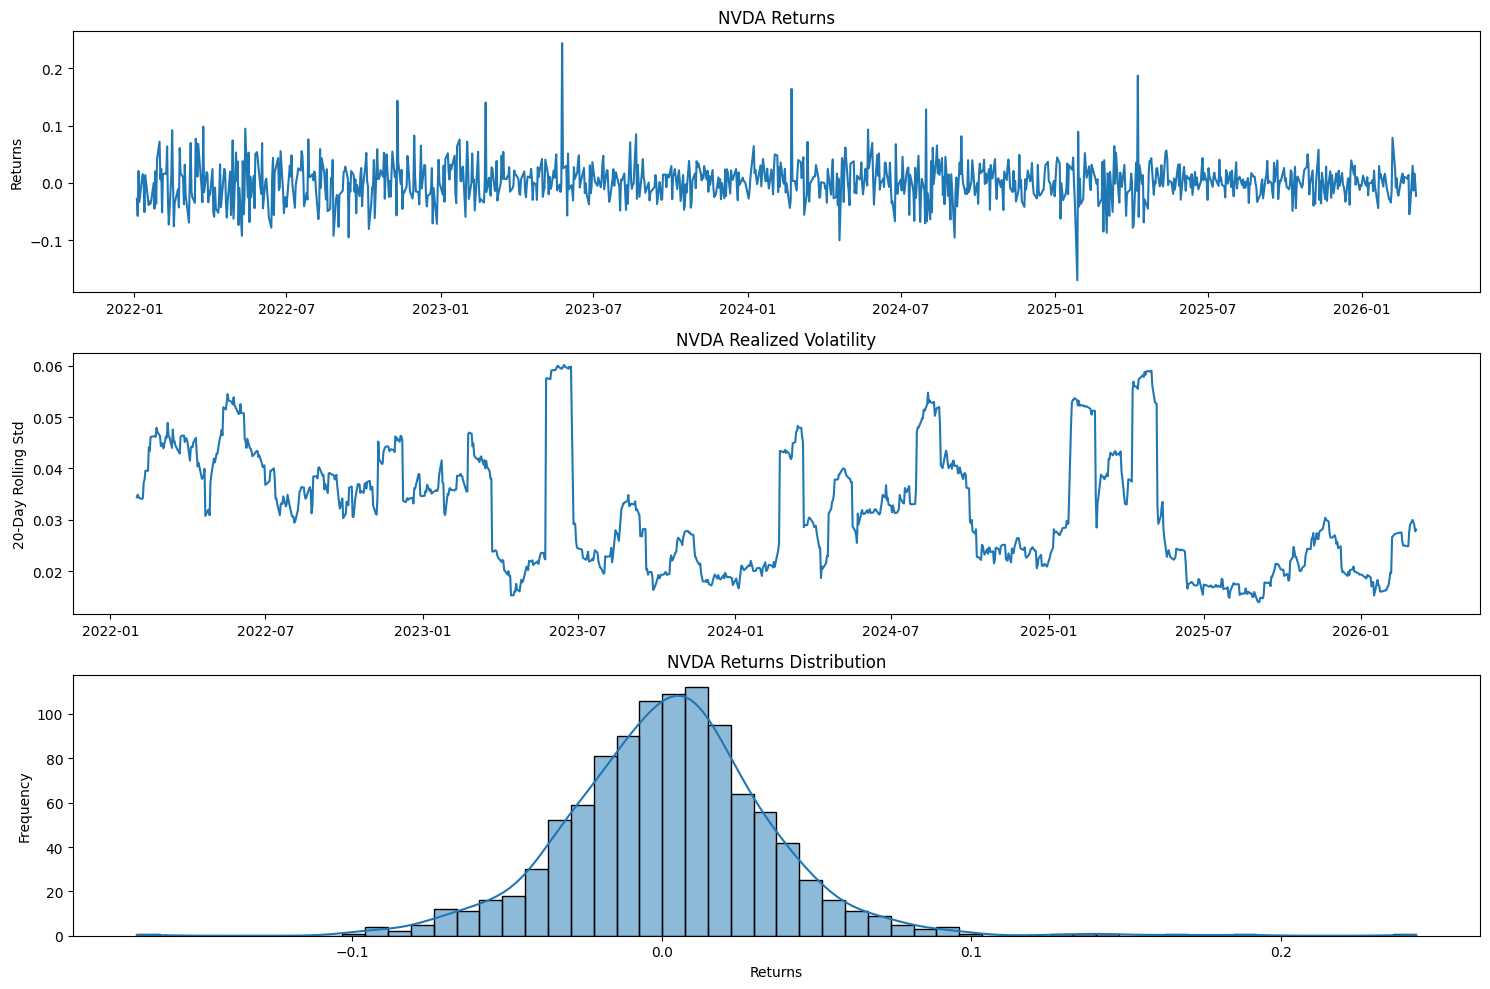

In [ ]:
!pip install arch -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    explained_variance_score
)

from statsmodels.tsa.stattools import adfuller
from arch import arch_model

class VolatilityForecaster:
    def __init__(self, tickers=['NVDA', 'AMD', 'INTC'], start_date='2022-01-01'):
        self.tickers = tickers
        self.start_date = start_date
        self.data = self._fetch_market_data()
        self.metrics = {}

    def _fetch_market_data(self):
        """
        Fetch multi-asset financial data with returns and volatility features
        """
        data = {}
        for ticker in self.tickers:
            stock_data = yf.download(ticker, start=self.start_date)
            stock_data['Returns'] = stock_data['Close'].pct_change()
            stock_data['Log_Returns'] = np.log(1 + stock_data['Returns'])
            stock_data['Realized_Volatility'] = stock_data['Returns'].rolling(window=20).std()
            data[ticker] = stock_data

        return data

    def test_stationarity(self, series):
        """
        Augmented Dickey-Fuller test for stationarity
        Returns stationarity boolean and detailed results
        """
        result = adfuller(series.dropna())
        return {
            'stationary': result[1] < 0.05,
            'p_value': result[1],
            'critical_values': result[4]
        }

    def garch_volatility_forecast(self, ticker, p=1, q=1, forecast_horizon=30):
        """
        GARCH model for volatility forecasting with comprehensive metrics
        """
        returns = self.data[ticker]['Returns'].dropna()

        # Rescale returns for better stability, apply a scaling factor if necessary
        scaling_factor = 1000  # Adjust scaling factor to bring data within a more stable range
        scaled_returns = returns * scaling_factor  # Rescale returns

        # Stationarity check
        stationarity_result = self.test_stationarity(scaled_returns)

        try:
            # Initialize and fit advanced GARCH model (GARCH(p,q))
            model = arch_model(scaled_returns, vol='Garch', p=p, q=q)  # GARCH(p,q)
            garch_results = model.fit(disp="off")
        except Exception as e:
            raise RuntimeError(f"Error fitting GARCH model for {ticker}: {e}")

        try:
            # Forecast volatility
            forecast = garch_results.forecast(horizon=forecast_horizon)
        except Exception as e:
            raise RuntimeError(f"Error generating forecast for {ticker}: {e}")

        # Calculate Performance Metrics
        metrics = self._calculate_forecast_metrics(scaled_returns, forecast)

        # Store metrics for this ticker
        self.metrics[ticker] = {
            'stationarity': stationarity_result,
            'volatility_forecast': forecast.variance.values[-1],
            'performance_metrics': metrics,
            'model_summary': str(garch_results.summary())
        }
        print("Shape of forecast.variance.values:", forecast.variance.values.shape)
        print("Forecast.variance.values:", forecast.variance.values)
        return self.metrics[ticker]




    def _calculate_forecast_metrics(self, actual_returns, forecast):
        # Extract forecasted variance
        forecast_vol_series = forecast.variance.values[-1]  # Last row of forecasted variance

        # Extract last n returns to compare against forecast
        last_n_returns = actual_returns[-len(forecast_vol_series):]

        # Ensure matching lengths
        if len(forecast_vol_series) != len(last_n_returns):
            forecast_vol_series = np.full_like(last_n_returns, np.mean(forecast_vol_series))

        # Calculate actual volatility
        actual_vol = np.std(last_n_returns)

        # Calculate performance metrics
        metrics = {
            'mean_squared_error': mean_squared_error(last_n_returns, forecast_vol_series),
            'mean_absolute_error': mean_absolute_error(last_n_returns, forecast_vol_series),
            'mean_absolute_percentage_error': mean_absolute_percentage_error(
                np.abs(last_n_returns), forecast_vol_series
            ),
            'forecast_volatility': np.mean(forecast_vol_series),
            'actual_volatility': actual_vol,
            'volatility_difference': abs(np.mean(forecast_vol_series) - actual_vol),
            'volatility_ratio': np.nan if actual_vol == 0 else np.mean(forecast_vol_series) / actual_vol,
            'explained_variance': explained_variance_score(np.abs(last_n_returns), forecast_vol_series),
        }

        return metrics







    def cross_validation_volatility(self, ticker, n_splits=5):
        """
        Time Series Cross-Validation for Volatility Forecasting
        """
        returns = self.data[ticker]['Returns'].dropna()
        tscv = TimeSeriesSplit(n_splits=n_splits)

        cv_metrics = []

        for train_index, test_index in tscv.split(returns):
            # Use .iloc[] for positional indexing
            train, test = returns.iloc[train_index], returns.iloc[test_index]

            # Fit GARCH on training data
            garch_model = arch_model(train).fit()
            forecast = garch_model.forecast(horizon=len(test))

            # Calculate metrics for this fold
            fold_metrics = self._calculate_forecast_metrics(test, forecast)
            cv_metrics.append(fold_metrics)

        return cv_metrics


    def visualize_volatility(self, ticker):
        """
        Create comprehensive volatility visualization
        """
        plt.figure(figsize=(15, 10))

        # Original Returns
        plt.subplot(3, 1, 1)
        plt.title(f'{ticker} Returns')
        plt.plot(self.data[ticker]['Returns'])
        plt.ylabel('Returns')

        # Realized Volatility
        plt.subplot(3, 1, 2)
        plt.title(f'{ticker} Realized Volatility')
        plt.plot(self.data[ticker]['Realized_Volatility'])
        plt.ylabel('20-Day Rolling Std')

        # Histogram of Returns
        plt.subplot(3, 1, 3)
        plt.title(f'{ticker} Returns Distribution')
        sns.histplot(self.data[ticker]['Returns'].dropna(), kde=True)
        plt.xlabel('Returns')
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

# Example Usage
forecaster = VolatilityForecaster()
nvda_volatility = forecaster.garch_volatility_forecast('NVDA')
print("NVDA Volatility Metrics:")
for key, value in nvda_volatility['performance_metrics'].items():
    print(f"{key}: {value}")

# Cross-Validation
cv_results = forecaster.cross_validation_volatility('NVDA')
print("\nCross-Validation Volatility Metrics:")
for i, fold_metrics in enumerate(cv_results, 1):
    print(f"Fold {i} Volatility Ratio: {fold_metrics['volatility_ratio']}")

# Visualization
forecaster.visualize_volatility('NVDA')